In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import os

WD =  os.getcwd()
BASE_DIR = os.path.abspath(os.path.join(WD, "..", ".."))
RESULTS = os.path.join(BASE_DIR, "data", "results", "anti", "anti_naive.csv")

df = pd.read_csv(RESULTS)

cols = [
    "build_time_us",
    "query_time_us",
    "memory_bytes"
]

for c in cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df["is_timeout"] = df["build_time_us"].isna()

In [35]:
clean = df[df["is_timeout"] == False]

clean["build_time_us"] = clean["build_time_us"] / 1000
clean["query_time_us"] = clean["query_time_us"] / 1000
clean["memory_bytes"] = clean["memory_bytes"] / (1024 * 1024)

clean = clean.rename(columns={
    "build_time_us": "build_time_ms",
    "query_time_us": "query_time_ms",
    "memory_bytes": "memory_mib"
})

In [36]:
summary = (
    clean.groupby(["dataset", "impl"])
        .agg(
            build_mean_ms=("build_time_ms", "mean"),
            build_std_ms=("build_time_ms", "std"),
            query_mean_ms=("query_time_ms", "mean"),
            query_std_ms=("query_time_ms", "std"),
            memory_mib=("memory_mib", "first"),
            num_pos=("positive_set_size", "first"),
            num_neg=("negative_set_size", "first"),
            num_queries=("number_of_queries", "first")
        )
        .reset_index()
)

summary["total_mean_ms"] = (
    summary["build_mean_ms"] +
    summary["query_mean_ms"]
)

summary["query_ms_per_query"] = (
    summary["query_mean_ms"] /
    summary["num_queries"]
)

summary["num_traces"] = (
    summary["num_pos"] +
    summary["num_neg"]
)

summary

,dataset,impl,build_mean_ms,build_std_ms,query_mean_ms,query_std_ms,memory_mib,num_pos,num_neg,num_queries,total_mean_ms,query_ms_per_query,num_traces
0,anti_naive1,naive,0.05550,0.014387,1109.31600,380.298772,0.041164,17,15,100000,1109.37150,0.011093,32
1,anti_naive1,sqrt,5.25250,1.613451,26.41750,7.018154,1.688099,17,15,100000,31.67000,0.000264,32
2,anti_naive2,naive,25.21025,9.310450,12417.46275,379.784292,27.033279,2,0,1000,12442.67300,12.417463,2
3,anti_naive2,sqrt,3122.00750,22.483186,0.04400,0.001633,1013.869190,2,0,1000,3122.05150,0.000044,2
4,anti_naive3,naive,1.41825,0.077899,24607.53600,2885.680521,1.582203,2,0,50000,24608.95425,0.492151,2
5,anti_naive3,sqrt,179.84725,21.159602,1.84175,0.030137,56.022327,2,0,50000,181.68900,0.000037,2
6,anti_naive4,naive,3.41500,1.270270,89373.25025,2728.871104,3.559948,102,100,100000,89376.66525,0.893733,202
7,anti_naive4,sqrt,474.44475,46.545039,4.77050,1.524917,143.749187,102,100,100000,479.21525,0.000048,202


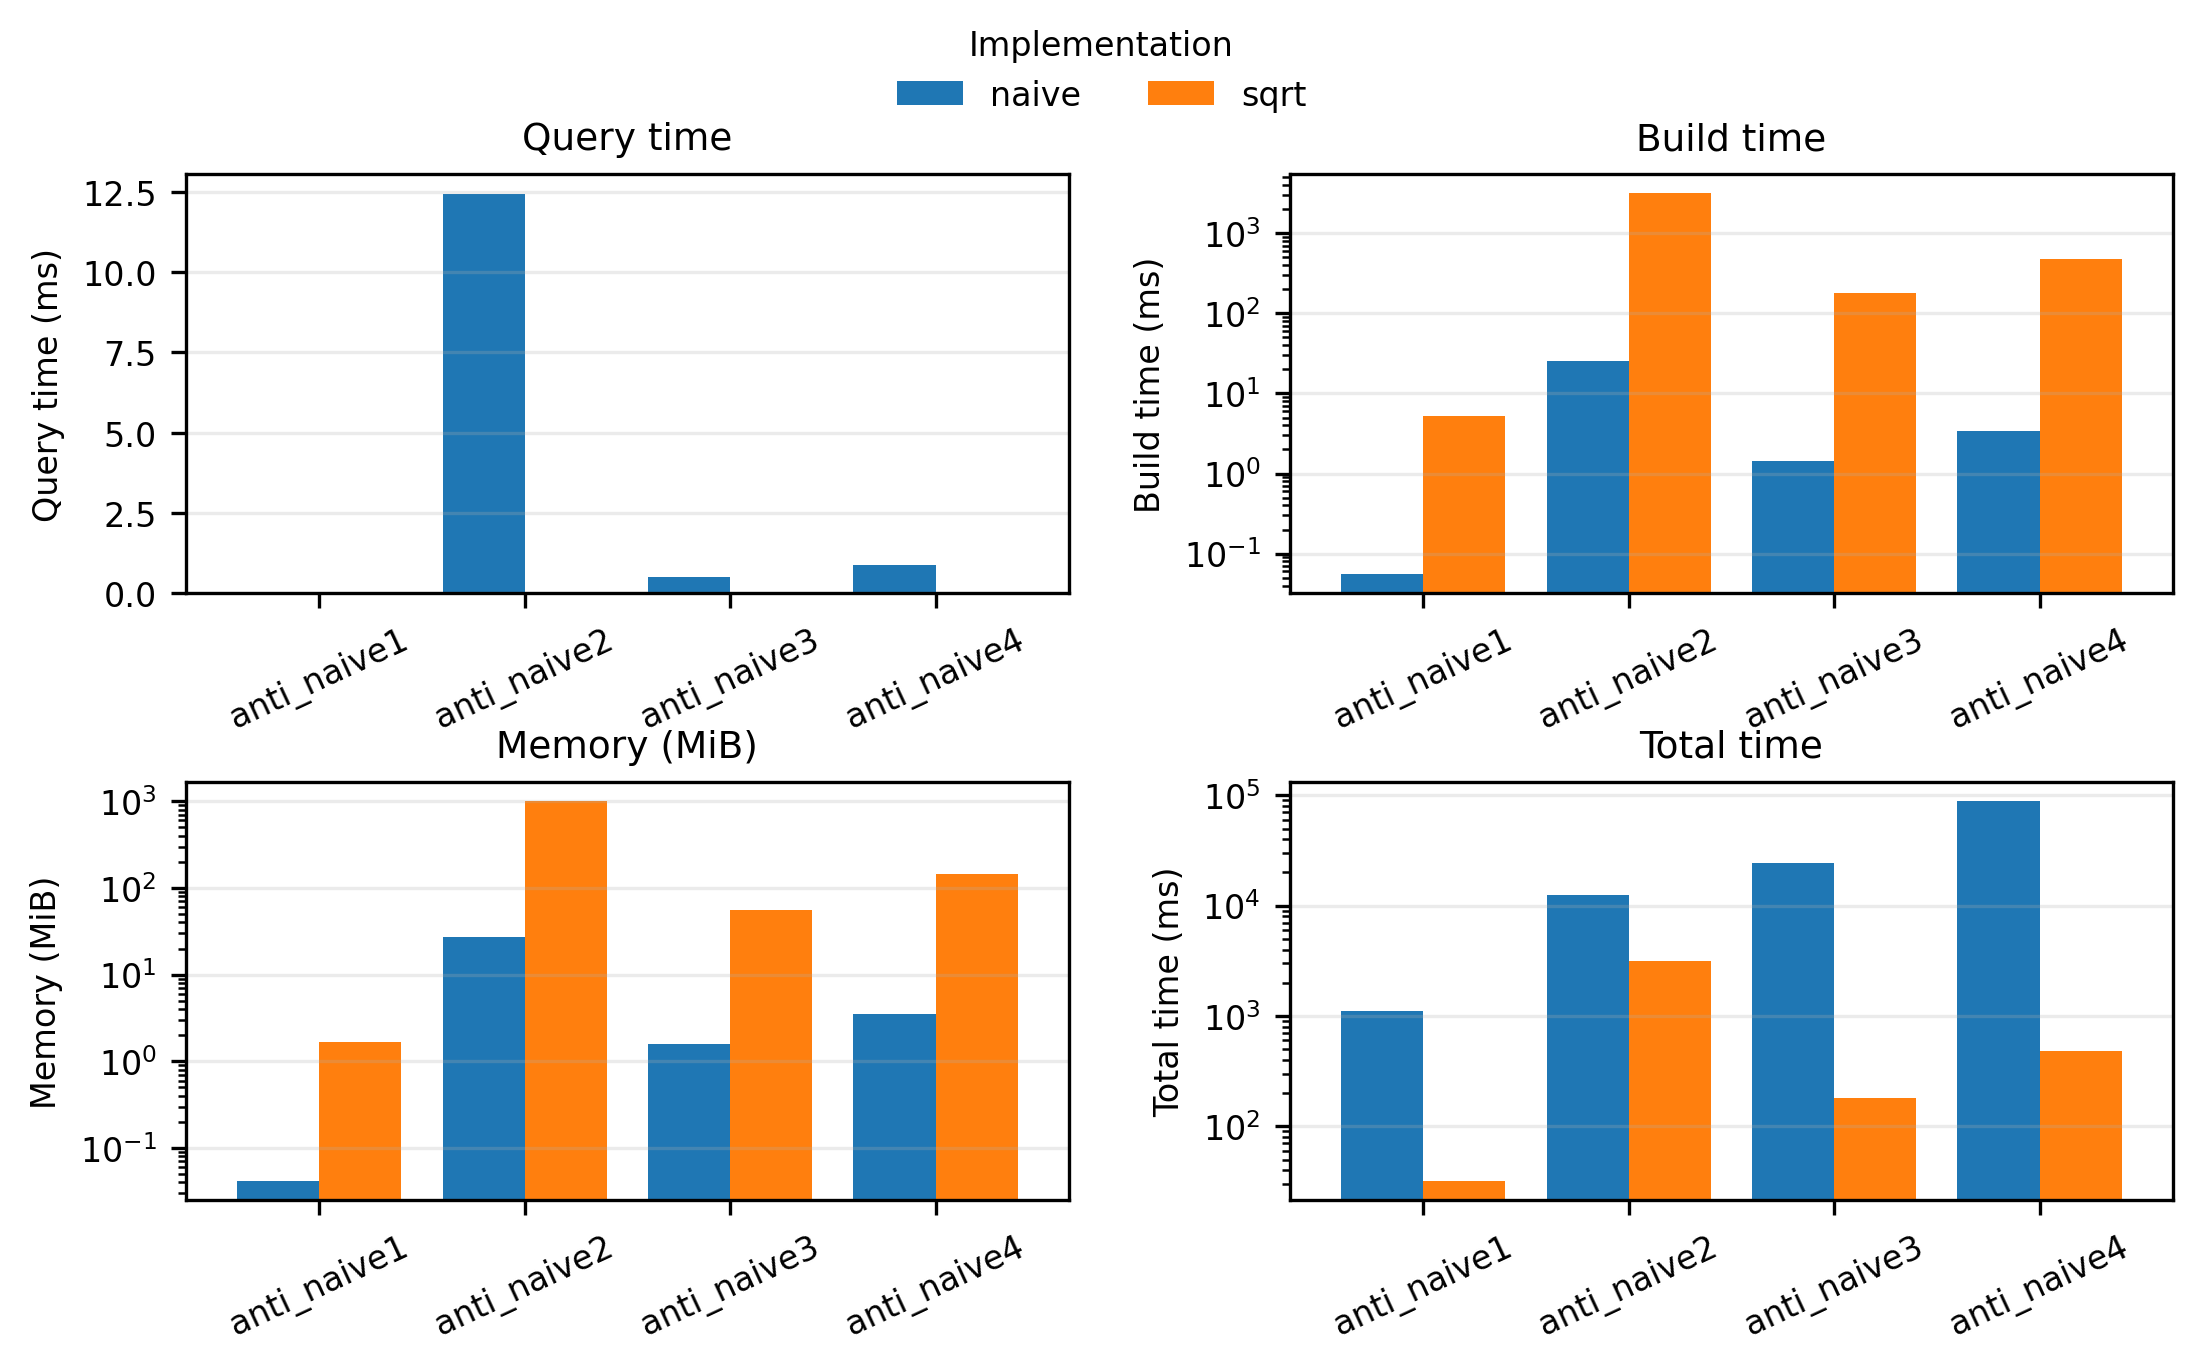

In [37]:
plt.rcParams.update({
    "font.size": 8,
    "axes.titlesize": 9,
    "axes.labelsize": 8,
})

fig, axes = plt.subplots(2, 2, figsize=(7.2, 4.5), dpi=300)

metrics = [
    ("query_ms_per_query", "Query time (ms)", False),
    ("build_mean_ms", "Build time (ms)", True),
    ("memory_mib", "Memory (MiB)", True),
    ("total_mean_ms", "Total time (ms)", True),
]

for ax, (metric, ylabel, use_log) in zip(axes.flat, metrics):
    pivot = summary.pivot(
        index="dataset",
        columns="impl",
        values=metric
    )

    pivot.plot(
        kind="bar",
        ax=ax,
        width=0.8
    )

    ax.set_title(ylabel.replace(" (ms)", "") if "ms" in ylabel else ylabel)
    ax.set_xlabel("")
    ax.set_ylabel(ylabel)

    if use_log:
        ax.set_yscale("log")

    ax.tick_params(axis="x", rotation=25)
    ax.grid(axis="y", alpha=0.25)

# single shared legend (clean placement)
handles, labels = axes[0, 0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    title="Implementation",
    loc="upper center",
    ncol=min(len(labels), 4),
    frameon=False,
)

# remove duplicate legends
for ax in axes.flat:
    ax.legend().remove()

plt.subplots_adjust(
    left=0.07,
    right=0.99,
    bottom=0.12,
    top=0.88,
    wspace=0.25,
    hspace=0.45
)

plt.show()

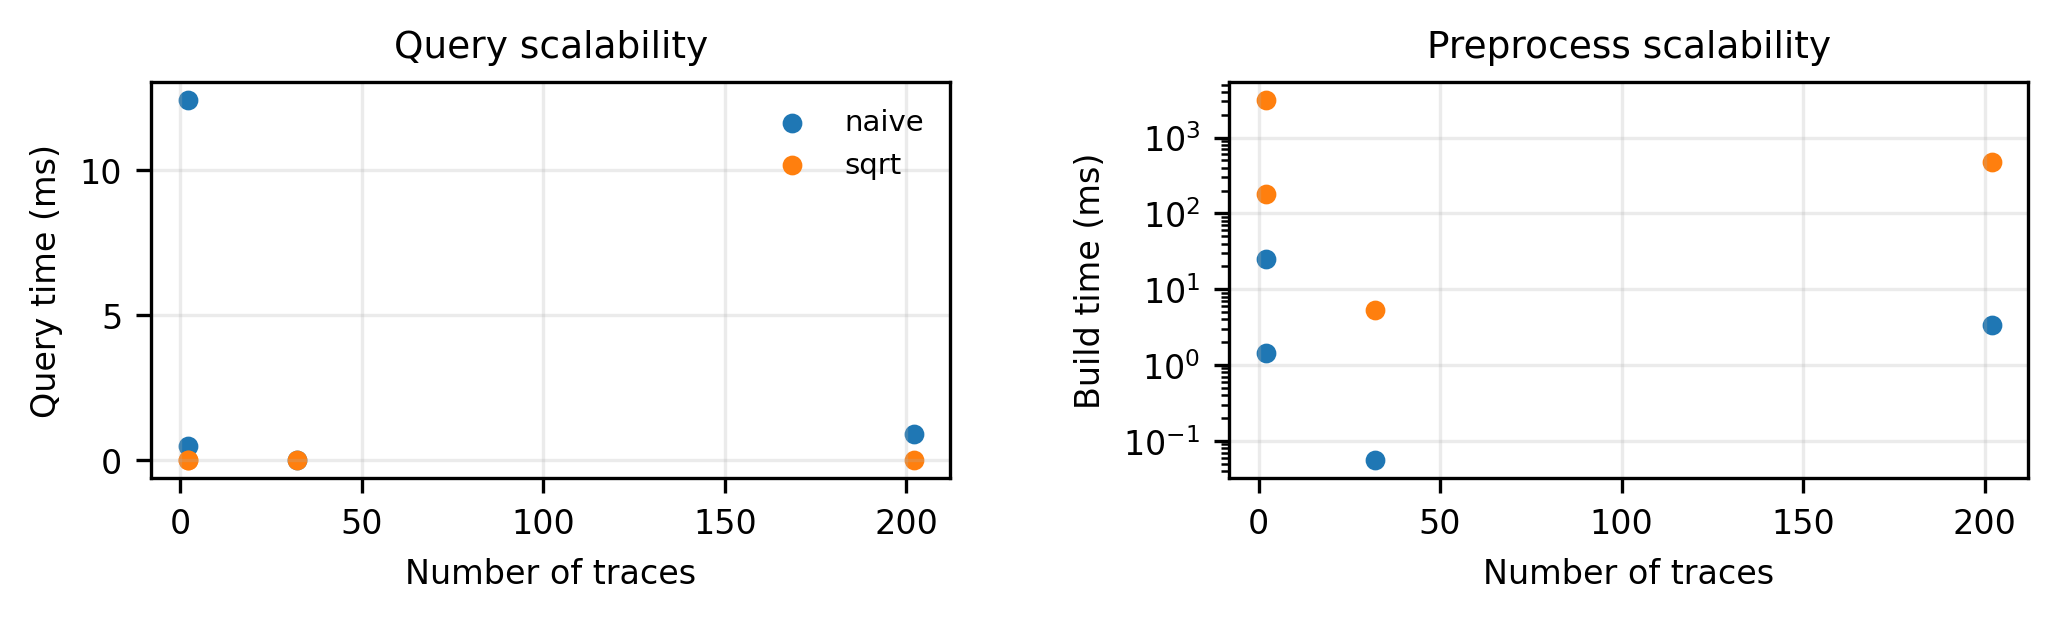

In [38]:
plt.rcParams.update({
    "font.size": 8,
    "axes.titlesize": 9,
    "axes.labelsize": 8,
})

fig, axes = plt.subplots(1, 2, figsize=(6.8, 2.2), dpi=300)

impls = summary["impl"].unique()

for impl in impls:
    sub = summary[summary["impl"] == impl].sort_values("num_traces")
    axes[0].scatter(
        sub["num_traces"],
        sub["query_ms_per_query"],
        s=14,
        label=impl
    )

axes[0].set_title("Query scalability")
axes[0].set_xlabel("Number of traces")
axes[0].set_ylabel("Query time (ms)")
axes[0].grid(alpha=0.25)
axes[0].legend(frameon=False, fontsize=7, loc="best")

for impl in impls:
    sub = summary[summary["impl"] == impl].sort_values("num_traces")
    axes[1].scatter(
        sub["num_traces"],
        sub["build_mean_ms"],
        s=14
    )

axes[1].set_title("Preprocess scalability")
axes[1].set_xlabel("Number of traces")
axes[1].set_ylabel("Build time (ms)")
axes[1].set_yscale("log")
axes[1].grid(alpha=0.25)

plt.subplots_adjust(
    left=0.07,
    right=0.99,
    bottom=0.25,
    top=0.85,
    wspace=0.35
)

plt.show()

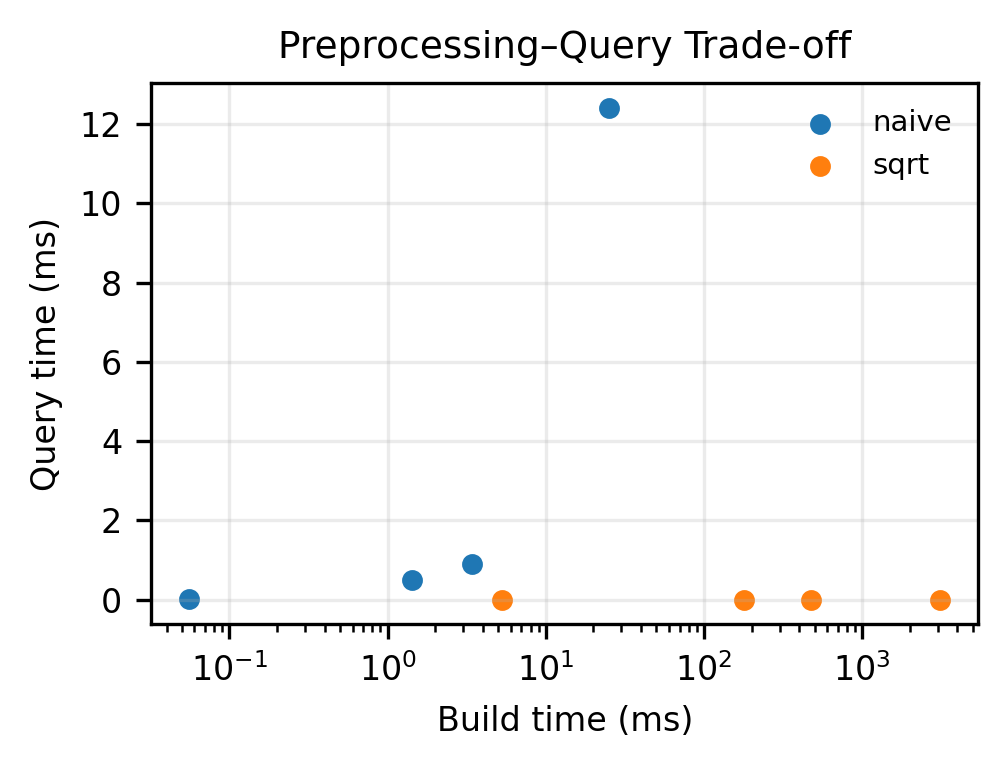

In [39]:
plt.rcParams.update({
    "font.size": 8,
    "axes.titlesize": 9,
    "axes.labelsize": 8,
})

fig, ax = plt.subplots(figsize=(3.4, 2.6), dpi=300)

impls = summary["impl"].unique()

for impl in impls:
    sub = summary[summary["impl"] == impl]
    ax.scatter(
        sub["build_mean_ms"],
        sub["query_ms_per_query"],
        s=16,
        label=impl
    )

ax.set_title("Preprocessing–Query Trade-off")
ax.set_xlabel("Build time (ms)")
ax.set_ylabel("Query time (ms)")
ax.set_xscale("log")
ax.grid(alpha=0.25)

ax.legend(frameon=False, fontsize=7)

plt.tight_layout()
plt.show()